In [4]:
from huggingface_hub import hf_hub_download
from pathlib import Path

SAM2_DIR = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\sam2')
SAM2_DIR.mkdir(parents=True, exist_ok=True)

print('下载 SAM2 权重（约 400MB）...')
ckpt_path = hf_hub_download(
    repo_id='facebook/sam2-hiera-large',
    filename='sam2_hiera_large.pt',
    local_dir=str(SAM2_DIR),
)
print(f'✓ 下载完成: {ckpt_path}')

# 同时下载配置文件
cfg_path = hf_hub_download(
    repo_id='facebook/sam2-hiera-large',
    filename='sam2_hiera_large.yaml',
    local_dir=str(SAM2_DIR),
)
print(f'✓ 配置文件: {cfg_path}')

c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


下载 SAM2 权重（约 400MB）...
✓ 下载完成: D:\geology AI\hls-foundation-os\pretrained_models\sam2\sam2_hiera_large.pt


RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-6a09b27c-022f6b73101109fd5aa50e0d;9fb4bbf0-6e86-4b36-9a2a-b26d7442f9c1)

Entry Not Found for url: https://huggingface.co/facebook/sam2-hiera-large/resolve/main/sam2_hiera_large.yaml.

In [5]:
import sam2
from pathlib import Path

# 找到 sam2 包的安装位置
sam2_package_dir = Path(sam2.__file__).parent
print(f'SAM2 包位置: {sam2_package_dir}')

# 查找配置文件
cfg_files = list(sam2_package_dir.rglob('*.yaml'))
print(f'\n找到 {len(cfg_files)} 个配置文件:')
for f in cfg_files:
    print(f'  {f.name}  →  {f}')

SAM2 包位置: c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2

找到 13 个配置文件:
  sam2_hiera_b+.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\sam2_hiera_b+.yaml
  sam2_hiera_l.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\sam2_hiera_l.yaml
  sam2_hiera_s.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\sam2_hiera_s.yaml
  sam2_hiera_t.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\sam2_hiera_t.yaml
  sam2_hiera_b+.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\configs\sam2\sam2_hiera_b+.yaml
  sam2_hiera_l.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\configs\sam2\sam2_hiera_l.yaml
  sam2_hiera_s.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\configs\sam2\sam2_hiera_s.yaml
  sam2_hiera_t.yaml  →  c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\sam2\configs\sam2\sam2_hiera_t.yaml
  sam2.1_hiera_b+.yaml  → 

In [6]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM2_CKPT = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\sam2\sam2_hiera_large.pt')
SAM2_CFG  = 'sam2_hiera_l.yaml'   # sam2 包会自动找到这个配置

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('加载 SAM2...')
sam2_model = build_sam2(SAM2_CFG, str(SAM2_CKPT), device=DEVICE)
predictor  = SAM2ImagePredictor(sam2_model)
print(f'✓ SAM2 加载成功')
print(f'  设备: {DEVICE}')

加载 SAM2...
✓ SAM2 加载成功
  设备: cuda


RGB 影像形状: (512, 512, 3)  dtype=uint8


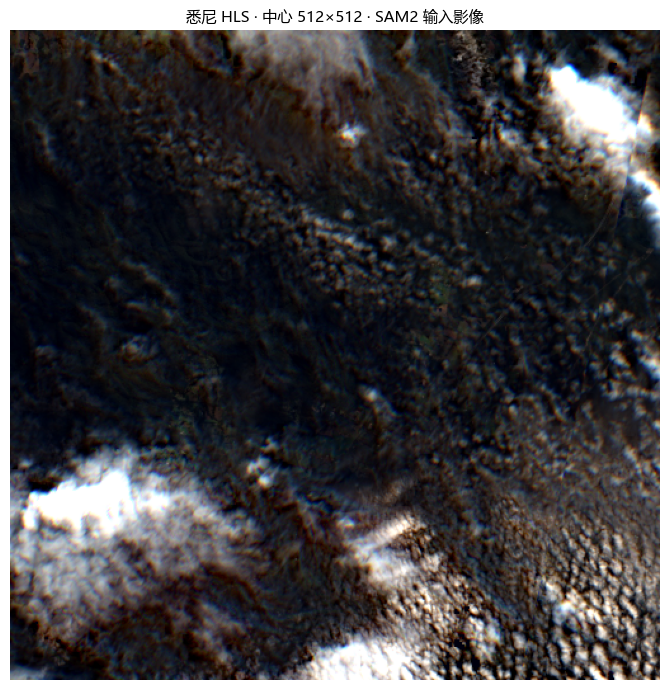

图已保存


In [7]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path(r'D:\geology AI\data\raw\hls_sample')
FIG_DIR  = Path(r'D:\geology AI\results\figures')
BANDS    = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']

# 读取全幅影像
def read_band(band_name):
    with rasterio.open(DATA_DIR / f'{band_name}.tif') as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = 0.0
    return arr

full_img = np.stack([read_band(b) for b in BANDS], axis=0)  # (6,3660,3660)
H, W = full_img.shape[1], full_img.shape[2]

# 裁剪中心 512×512 区域（SAM2 处理更快）
cy, cx = H//2, W//2
P = 512
crop = full_img[:, cy-P//2:cy+P//2, cx-P//2:cx+P//2]  # (6,512,512)

# 生成 RGB 图（SAM2 需要 uint8 RGB）
def make_rgb_uint8(img, p_low=2, p_high=98):
    rgb = img[[2, 1, 0]].copy()   # B04 B03 B02
    for i in range(3):
        lo, hi = np.percentile(rgb[i], [p_low, p_high])
        rgb[i] = np.clip((rgb[i] - lo) / (hi - lo + 1e-8), 0, 1)
    rgb = (rgb * 255).astype(np.uint8)
    return rgb.transpose(1, 2, 0)  # (H,W,3)

rgb_img = make_rgb_uint8(crop)
print(f'RGB 影像形状: {rgb_img.shape}  dtype={rgb_img.dtype}')

plt.figure(figsize=(7, 7))
plt.imshow(rgb_img)
plt.title('悉尼 HLS · 中心 512×512 · SAM2 输入影像', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_12_sam2_input.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

In [8]:
# 设置影像
predictor.set_image(rgb_img)
print('✓ 影像已载入 SAM2')

# 定义提示点（点击感兴趣区域）
# 坐标格式：(x, y)，原点在左上角
# 根据影像目视判断：
#   亮白区域（云/裸地）约在左下 (100, 380)
#   深色植被区域约在右上 (400, 100)
#   中间过渡带约在 (256, 256)

import numpy as np

# 正样本点（想要分割的区域）+ 负样本点（不想要的区域）
point_coords = np.array([
    [100, 380],   # 亮白区域（裸土/云）← 正样本
    [400, 100],   # 深色植被            ← 负样本
])
point_labels = np.array([1, 0])   # 1=正样本  0=负样本

# SAM2 推理
with torch.inference_mode():
    masks, scores, logits = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True,   # 返回多个候选掩码
    )

print(f'生成掩码数量: {masks.shape[0]}')
print(f'各掩码得分:   {scores}')
print(f'最佳掩码得分: {scores.max():.3f}（index={scores.argmax()}）')

✓ 影像已载入 SAM2
生成掩码数量: 3
各掩码得分:   [0.6870737  0.04087345 0.34942687]
最佳掩码得分: 0.687（index=0）


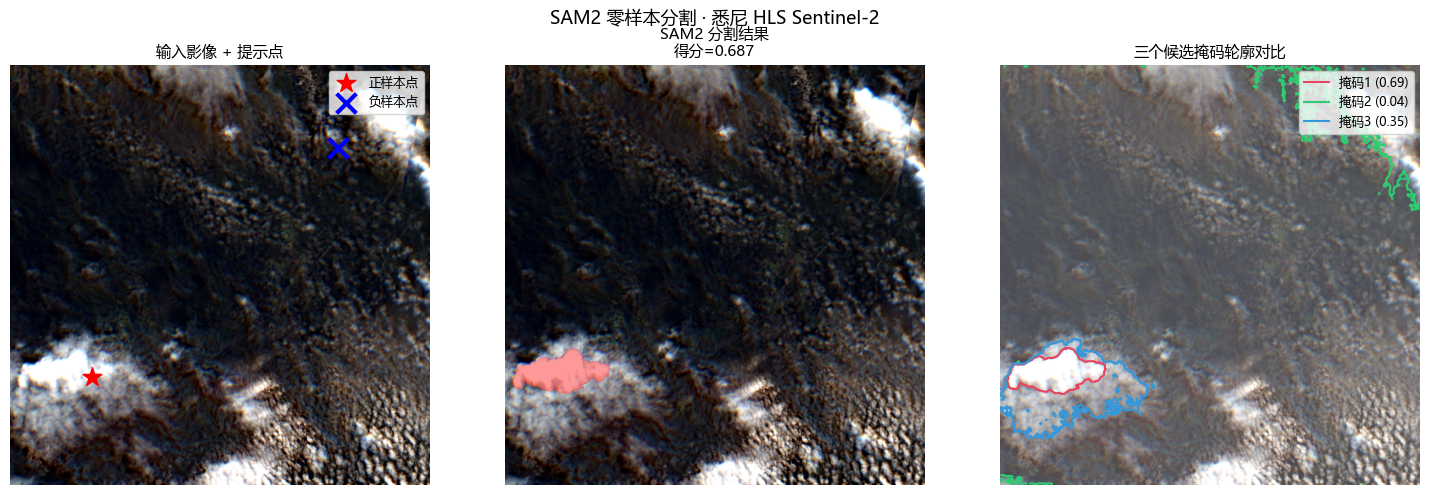

分割面积: 4013 像素 (1.5%)


In [10]:
best_mask = masks[scores.argmax()].astype(bool)  # ← 加 .astype(bool)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 原始影像 + 提示点
axes[0].imshow(rgb_img)
axes[0].scatter(point_coords[0,0], point_coords[0,1],
                c='red', s=200, marker='*', zorder=5, label='正样本点')
axes[0].scatter(point_coords[1,0], point_coords[1,1],
                c='blue', s=200, marker='x', zorder=5, label='负样本点', linewidths=3)
axes[0].set_title('输入影像 + 提示点', fontsize=11)
axes[0].legend(fontsize=9); axes[0].axis('off')

# 最佳掩码叠加
axes[1].imshow(rgb_img)
mask_overlay = np.zeros((*best_mask.shape, 4), dtype=np.float32)
mask_overlay[best_mask] = [1.0, 0.2, 0.2, 0.5]
axes[1].imshow(mask_overlay)
axes[1].set_title(f'SAM2 分割结果\n得分={scores.max():.3f}', fontsize=11)
axes[1].axis('off')

# 三个候选掩码轮廓
axes[2].imshow(rgb_img, alpha=0.7)
for i, (mask, score) in enumerate(zip(masks, scores)):
    axes[2].contour(mask.astype(bool), levels=[0.5],
                    colors=[['#e94560','#2ecc71','#3498db'][i]],
                    linewidths=1.5)
    axes[2].plot([], [], color=['#e94560','#2ecc71','#3498db'][i],
                 label=f'掩码{i+1} ({score:.2f})')
axes[2].set_title('三个候选掩码轮廓对比', fontsize=11)
axes[2].legend(fontsize=9); axes[2].axis('off')

plt.suptitle('SAM2 零样本分割 · 悉尼 HLS Sentinel-2', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_12_sam2_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'分割面积: {best_mask.sum()} 像素 ({best_mask.mean()*100:.1f}%)')

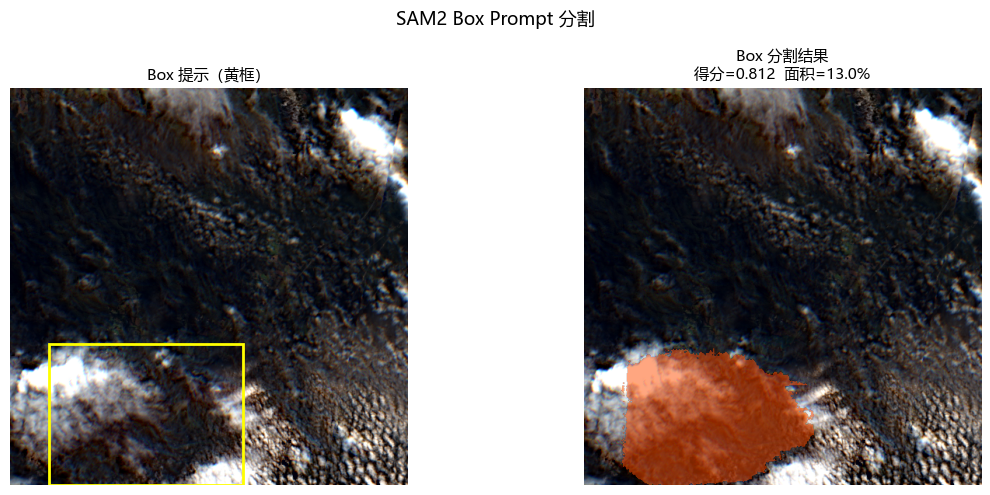

In [11]:
# 用边界框（Box Prompt）分割亮白区域
# Box 格式：[x_min, y_min, x_max, y_max]
box = np.array([50, 330, 300, 512])   # 左下亮白区域

with torch.inference_mode():
    masks_box, scores_box, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=box,
        multimask_output=False,
    )

best_box_mask = masks_box[0].astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左：Box 提示
axes[0].imshow(rgb_img)
rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                       linewidth=2, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Box 提示（黄框）', fontsize=11)
axes[0].axis('off')

# 右：分割结果
axes[1].imshow(rgb_img)
overlay = np.zeros((*best_box_mask.shape, 4), dtype=np.float32)
overlay[best_box_mask] = [1.0, 0.3, 0.0, 0.5]
axes[1].imshow(overlay)
axes[1].set_title(f'Box 分割结果\n得分={scores_box[0]:.3f}  面积={best_box_mask.mean()*100:.1f}%',
                  fontsize=11)
axes[1].axis('off')

plt.suptitle('SAM2 Box Prompt 分割', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'week3_12_sam2_box.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import subprocess, os

REPO_DIR = r'D:\geology AI'
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)

git('git add notebooks/12_sam2_segmentation.ipynb')
git('git add results/figures/week3_12_sam2_input.png')
git('git add results/figures/week3_12_sam2_result.png')
git('git add results/figures/week3_12_sam2_box.png')
git('git commit -m "Week3 Day3: SAM2 zero-shot segmentation, point score=0.687, box score=0.812"')
git('git push origin main')
print('\n✓ Day 3 已推送到 GitHub')

[main c8f8ced] Week3 Day3: SAM2 zero-shot segmentation, point score=0.687, box score=0.812
 4 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 notebooks/12_sam2_segmentation.ipynb
 create mode 100644 results/figures/week3_12_sam2_box.png
 create mode 100644 results/figures/week3_12_sam2_input.png
 create mode 100644 results/figures/week3_12_sam2_result.png
To https://github.com/lofophil/geo-foundation-experiments.git
   8b0c2d4..c8f8ced  main -> main

✓ Day 3 已推送到 GitHub
